## Assignment-19 Natural Language Processing(NLP)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load dataset (TSV file)
import os

file_path = 'Data\amazonreviews.tsv'

if os.path.exists(file_path):
    data = pd.read_csv(file_path, sep='\t')
else:
    print("Dataset file not found. Please place amazonreviews.tsv in the working directory.")


In [3]:
print(data.head())

  label                                             review
0   pos  Stuning even for the non-gamer: This sound tra...
1   pos  The best soundtrack ever to anything.: I'm rea...
2   pos  Amazing!: This soundtrack is my favorite music...
3   pos  Excellent Soundtrack: I truly like this soundt...
4   pos  Remember, Pull Your Jaw Off The Floor After He...


In [4]:
print(data.shape)

(10000, 2)


In [5]:
# data cleaning

In [6]:
# removing duplicates

data.drop_duplicates(inplace = True)

In [7]:
# removing missing values

data.dropna(inplace = True)

In [8]:
print(data.shape)

(10000, 2)


In [9]:
print(data.isnull().sum())

label     0
review    0
dtype: int64


##### Text Preprocessing

In [10]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = text.lower()  # lowercase
    text = re.sub(r'[^a-zA-Z]', ' ', text)  # remove special chars
    words = text.split()
    words = [w for w in words if w not in stop_words]  # remove stopwords
    return " ".join(words)

data['clean_review'] = data['review'].apply(preprocess)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\javee\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


##### Exploratory Data Analysis

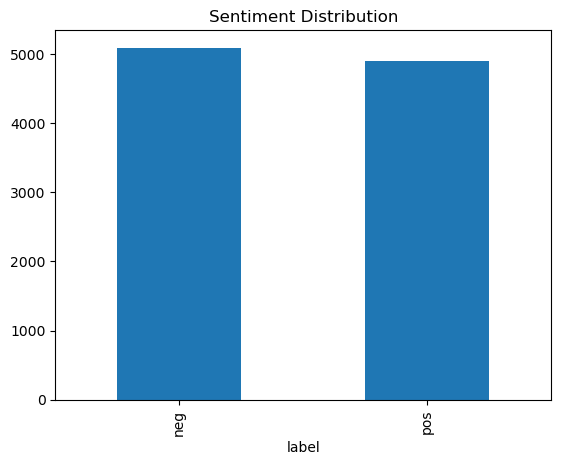

In [11]:
#Sentiment Distribution

data['label'].value_counts().plot(kind='bar')
plt.title('Sentiment Distribution')
plt.show()

In [12]:
#!pip install wordcloud

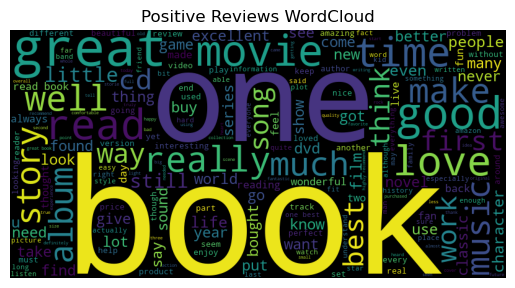

In [13]:
# Word Cloud
from wordcloud import WordCloud

# Positive reviews
pos_text = " ".join(data[data['label']=='pos']['clean_review'])
wc = WordCloud(width=800, height=400).generate(pos_text)

plt.imshow(wc)
plt.axis('off')
plt.title("Positive Reviews WordCloud")
plt.show()

##### Feature Extraction (TF-IDF)

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(data['clean_review']).toarray()
y = data['label'].map({'pos':1, 'neg':0})

##### Train_Test_Split

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
X_train,X_test,y_train,y_test = train_test_split(X,
                                                y,
                                                test_size=0.2,
                                                random_state=42
                                                )
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((8000, 5000), (2000, 5000), (8000,), (2000,))

##### Model Building

Logistic Regression

In [17]:
from sklearn.linear_model import LogisticRegression

In [18]:
model_lr = LogisticRegression()
model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)

##### Support Vector Machine (SVM)

In [ ]:
from sklearn.svm import SVC

model_svm = SVC()
model_svm.fit(X_train, y_train)

y_pred_svm = model_svm.predict(X_test)

##### Evalutaion

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

##### Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10]
}

grid = GridSearchCV(LogisticRegression(), param_grid, cv=3)
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

##### Artificial Neural Networks

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model_ann = Sequential()
model_ann.add(Dense(128, activation='relu', input_dim=X.shape[1]))
model_ann.add(Dense(64, activation='relu'))
model_ann.add(Dense(1, activation='sigmoid'))

model_ann.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

model_ann.fit(X_train, y_train, epochs=5, batch_size=32)

##### Conclusion:

The sentiment analysis model successfully classified customer reviews into positive and negative categories. TF-IDF was effective in converting text into numerical features. Logistic Regression provided a good baseline, while SVM achieved competitive performance. Hyperparameter tuning further improved accuracy. This system can help businesses monitor customer sentiment and take proactive actions to improve customer satisfaction.